In [1]:
import pickle, copy, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib as mpl
import matplotlib.cm as cm
import scipy.stats as sps
from random import shuffle
import itertools

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
#import la_forge.utils as lf_utils
#lf_utils.set_publication_params({'text.usetex':False})
#fig_dir = '/home/baierj/projects/hasasia2/hasasia2_paper/figures'

In [2]:
import healpy as hp
import astropy.units as u
import astropy.constants as c
from astropy.coordinates import SkyCoord
#import plot #Script originally written by Leo Stein for making pretty sky maps. 

# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

In [3]:
import numpy as np
import scipy.linalg as sl
import matplotlib.pyplot as plt
%matplotlib inline
import glob, pickle, json
import hasasia.sensitivity as hsen
import hasasia.sim as hsim
import hasasia.skymap as hsky
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['figure.figsize'] = [5,3]
mpl.rcParams['text.usetex'] = True
from enterprise.pulsar import Pulsar as ePulsar
ng20_irn = '/Users/ashokan/osu/sarahspta/NG20_irn/'
pardir = ng20_irn
timdir = ng20_irn
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))

/opt/homebrew/Caskroom/mambaforge/base/envs/sarahspta/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


In [250]:
pars[0]

'/Users/ashokan/osu/sarahspta/NG20_irn/B1855+09.par'

In [251]:
tims[0]

'/Users/ashokan/osu/sarahspta/NG20_irn/B1855+09.tim'

In [252]:
ePsrs = []
for par,tim in zip(pars,tims):
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

2025-10-03 14:50:03.378 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-03 14:50:03.532 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-03 14:50:03.537 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-03 14:50:03.548 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:50:03.550 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-03 14:50:03.551 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-03 14:50:03.626 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:50:03.627 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR B1855+09 complete

2025-10-03 14:50:04.951 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-03 14:50:05.043 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-03 14:50:05.045 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-03 14:50:05.051 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:50:05.052 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-03 14:50:05.052 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-03 14:50:05.088 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:50:05.089 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR B1953+29 complete

2025-10-03 14:50:06.160 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-03 14:50:06.286 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-03 14:50:06.295 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-03 14:50:06.310 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:50:06.311 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-03 14:50:06.312 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-03 14:50:06.878 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:50:06.880 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

...

PSR J2302+4442 complete

2025-10-03 14:51:34.663 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-03 14:51:34.847 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-03 14:51:34.851 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-03 14:51:34.866 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:51:34.868 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-03 14:51:34.869 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-03 14:51:34.989 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:51:34.989 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2317+1439 complete

2025-10-03 14:51:36.203 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-10-03 14:51:36.283 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-03 14:51:36.285 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-03 14:51:36.289 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:51:36.290 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-10-03 14:51:36.291 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-03 14:51:36.318 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-03 14:51:36.319 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2322+2057 complete

In [344]:
def make_corr(psr,noise):
    N = psr.toaerrs.size
    corr = np.zeros((N,N))
    _, _, fl, _, bi = hsen.quantize_fast(psr.toas,psr.toaerrs,
                                         flags=psr.flags['f'],dt=1)
    keys = [ky for ky in noise.keys() if psr.name in ky]
    backends = np.unique(psr.flags['f'])
    sigma_sqr = np.zeros(N)
    ecorrs = np.zeros_like(fl,dtype=float)
    for be in backends:
        mask = np.where(psr.flags['f']==be)
        key_ef = '{0}_{1}_{2}'.format(psr.name,be,'efac')
        key_eq = '{0}_{1}_log10_{2}'.format(psr.name,be,'equad')
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        sigma_sqr[mask] = (noise[key_ef]**2 * ((psr.toaerrs[mask]**2)
                           + (10**noise[key_eq])**2)+(10**noise[key_ec])**2)
        mask_ec = np.where(fl==be)
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        ecorrs[mask_ec] = np.ones_like(mask_ec) * (10**noise[key_ec])
    j = [ecorrs[ii]**2*np.ones((len(bucket),len(bucket)))
         for ii, bucket in enumerate(bi)]

    J = sl.block_diag(*j)
    corr = np.diag(sigma_sqr) + J
    return corr

In [345]:
def make_corr_our(psr):
    sigma_sqrt = psr.toaerrs**2
    corr = np.diag(sigma_sqrt)
    return corr


In [284]:
noise_dir = '/Users/ashokan/osu/sarahspta/'#20yr_noisedict_rn+curn-bpl/'
noise_files = '/Users/ashokan/osu/sarahspta/20yr_noisedict_rn+curn-bpl.json'
noise_files

'/Users/ashokan/osu/sarahspta/20yr_noisedict_rn+curn-bpl.json'

In [285]:
import json
with open(noise_files,'r') as f:
    noise = json.load(f)

In [286]:
rn_psrs = noise
print(rn_psrs)

{'B1855+09_red_noise_gamma': 4.131720100411879, 'B1855+09_red_noise_log10_A': -14.283134228701593, 'B1937+21_red_noise_gamma': 2.372077003631106, 'B1937+21_red_noise_log10_A': -12.779210971140605, 'B1953+29_red_noise_gamma': 2.246346131593814, 'B1953+29_red_noise_log10_A': -12.774023346685262, 'J0023+0923_red_noise_gamma': 0.1992954711011312, 'J0023+0923_red_noise_log10_A': -12.49852143026507, 'J0030+0451_red_noise_gamma': 5.220711432902525, 'J0030+0451_red_noise_log10_A': -14.823656247523614, 'J0102+4839_red_noise_gamma': 2.8136105227140513, 'J0102+4839_red_noise_log10_A': -12.274238594589225, 'J0125-2327_red_noise_gamma': 1.362665710133176, 'J0125-2327_red_noise_log10_A': -17.523352111518513, 'J0154+1833_red_noise_gamma': 0.2014365329849749, 'J0154+1833_red_noise_log10_A': -15.416251404217899, 'J0218+4232_red_noise_gamma': 0.5462921162310412, 'J0218+4232_red_noise_log10_A': -11.570982211465163, 'J0340+4130_red_noise_gamma': 0.2721532889980398, 'J0340+4130_red_noise_log10_A': -12.8066

In [287]:
nihans_dict = '/Users/ashokan/osu/sarahspta/15yr_v1_fl_fwn_dict.json'
with open(nihans_dict,'r') as f:
    nihans_noise = json.load(f)

In [288]:
nihans_noise

{'B1855+09_430_ASP_efac': 1.0952941083653116,
 'B1855+09_430_ASP_log10_ecorr': -8.491311799818622,
 'B1855+09_430_ASP_log10_equad': -6.830689524145644,
 'B1855+09_430_PUPPI_efac': 0.9993695969853792,
 'B1855+09_430_PUPPI_log10_ecorr': -5.72243053442663,
 'B1855+09_430_PUPPI_log10_equad': -6.402031561742483,
 'B1855+09_L-wide_ASP_efac': 1.0244127763116193,
 'B1855+09_L-wide_ASP_log10_ecorr': -6.097057879717841,
 'B1855+09_L-wide_ASP_log10_equad': -6.481015807255515,
 'B1855+09_L-wide_PUPPI_efac': 1.1004705572093467,
 'B1855+09_L-wide_PUPPI_log10_ecorr': -6.643946570100447,
 'B1855+09_L-wide_PUPPI_log10_equad': -7.266611429595852,
 'B1855+09_red_noise_gamma': 3.6128353448907142,
 'B1855+09_red_noise_log10_A': -13.902575986007228,
 'B1937+21_L-wide_ASP_efac': 2.20289447487106,
 'B1937+21_L-wide_ASP_log10_ecorr': -6.923818483058105,
 'B1937+21_L-wide_ASP_log10_equad': -6.823019703076379,
 'B1937+21_L-wide_PUPPI_efac': 1.5528476452175854,
 'B1937+21_L-wide_PUPPI_log10_ecorr': -6.92713616913

In [289]:
Tspan = hsen.get_Tspan(ePsrs)
fyr = 1/(365.25*24*3600)
freqs = np.logspace(np.log10(1/(5*Tspan)),np.log10(2e-7),600)

In [290]:
Tspan/(365*86400)

np.longdouble('20.634273326866975')

In [291]:
ng20_noise_dict = '/Users/ashokan/osu/sarahspta/ng20_v1p1_dmx_noise_dict.json'
#from https://drive.google.com/drive/folders/1GQXnpyRglqPHwgQs6vE8VK-6VoL9WbSj
with open(ng20_noise_dict,'r') as f:
    ng20_noise_real = json.load(f)

In [292]:
ng20_noise_real

{'B1855+09_430_ASP_efac': 1.158963728839342,
 'B1855+09_430_ASP_log10_ecorr': -7.454005000831911,
 'B1855+09_430_ASP_log10_t2equad': -7.465514539957289,
 'B1855+09_430_PUPPI_efac': 1.0191752429233873,
 'B1855+09_430_PUPPI_log10_ecorr': -6.19762265347091,
 'B1855+09_430_PUPPI_log10_t2equad': -6.68557139992855,
 'B1855+09_CHIME_efac': 0.9576629507758594,
 'B1855+09_CHIME_log10_ecorr': -7.485146600960501,
 'B1855+09_CHIME_log10_t2equad': -7.277761761501743,
 'B1855+09_L-wide_ASP_efac': 1.173089201118123,
 'B1855+09_L-wide_ASP_log10_ecorr': -6.110205636255204,
 'B1855+09_L-wide_ASP_log10_t2equad': -6.5905557986246235,
 'B1855+09_L-wide_PUPPI_efac': 1.2843581837455045,
 'B1855+09_L-wide_PUPPI_log10_ecorr': -6.465263275548019,
 'B1855+09_L-wide_PUPPI_log10_t2equad': -8.13403683681612,
 'B1855+09_Rcvr1_2_VEGAS_efac': 1.0491085140124021,
 'B1855+09_Rcvr1_2_VEGAS_log10_ecorr': -7.170487732418092,
 'B1855+09_Rcvr1_2_VEGAS_log10_t2equad': -7.322750828740293,
 'B1855+09_red_noise_gamma': 3.4126912

In [293]:
chime_vegas_noise_dict = {}

for k, v in ng20_noise_real.items():
    new_key = k.replace("t2equad", "equad")
    if "CHIME" in k or "YUPPI" in k or "VEGAS" in k or "J0125-2327" in k or "J0154+1833" in k or "J0614-3329" in k or "J0621+2514" in k or "J0732+2314" in k or "J0751+1807" in k or "J1022+1001" in k or "J1803+1358" in k or "J2022+2534" in k or "J2039-3616" in k or "J2150-0326" in k:
        print(k)
        chime_vegas_noise_dict[new_key] = v


B1855+09_CHIME_efac
B1855+09_CHIME_log10_ecorr
B1855+09_CHIME_log10_t2equad
B1855+09_Rcvr1_2_VEGAS_efac
B1855+09_Rcvr1_2_VEGAS_log10_ecorr
B1855+09_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_3GHz_YUPPI_efac
B1937+21_3GHz_YUPPI_log10_ecorr
B1937+21_3GHz_YUPPI_log10_t2equad
B1937+21_CHIME_efac
B1937+21_CHIME_log10_ecorr
B1937+21_CHIME_log10_t2equad
B1937+21_Rcvr1_2_VEGAS_efac
B1937+21_Rcvr1_2_VEGAS_log10_ecorr
B1937+21_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_Rcvr_800_VEGAS_efac
B1937+21_Rcvr_800_VEGAS_log10_ecorr
B1937+21_Rcvr_800_VEGAS_log10_t2equad
B1953+29_CHIME_efac
B1953+29_CHIME_log10_ecorr
B1953+29_CHIME_log10_t2equad
J0023+0923_CHIME_efac
J0023+0923_CHIME_log10_ecorr
J0023+0923_CHIME_log10_t2equad
J0023+0923_Rcvr1_2_VEGAS_efac
J0023+0923_Rcvr1_2_VEGAS_log10_ecorr
J0023+0923_Rcvr1_2_VEGAS_log10_t2equad
J0030+0451_CHIME_efac
J0030+0451_CHIME_log10_ecorr
J0030+0451_CHIME_log10_t2equad
J0030+0451_Rcvr1_2_VEGAS_efac
J0030+0451_Rcvr1_2_VEGAS_log10_ecorr
J0030+0451_Rcvr1_2_VEGAS_log10_t2equad
J0

In [294]:
len(chime_vegas_noise_dict)

616

In [295]:
nihans_noise.update(chime_vegas_noise_dict)

In [296]:
len(nihans_noise)

1364

In [297]:
nihans_noise

{'B1855+09_430_ASP_efac': 1.0952941083653116,
 'B1855+09_430_ASP_log10_ecorr': -8.491311799818622,
 'B1855+09_430_ASP_log10_equad': -6.830689524145644,
 'B1855+09_430_PUPPI_efac': 0.9993695969853792,
 'B1855+09_430_PUPPI_log10_ecorr': -5.72243053442663,
 'B1855+09_430_PUPPI_log10_equad': -6.402031561742483,
 'B1855+09_L-wide_ASP_efac': 1.0244127763116193,
 'B1855+09_L-wide_ASP_log10_ecorr': -6.097057879717841,
 'B1855+09_L-wide_ASP_log10_equad': -6.481015807255515,
 'B1855+09_L-wide_PUPPI_efac': 1.1004705572093467,
 'B1855+09_L-wide_PUPPI_log10_ecorr': -6.643946570100447,
 'B1855+09_L-wide_PUPPI_log10_equad': -7.266611429595852,
 'B1855+09_red_noise_gamma': 3.6128353448907142,
 'B1855+09_red_noise_log10_A': -13.902575986007228,
 'B1937+21_L-wide_ASP_efac': 2.20289447487106,
 'B1937+21_L-wide_ASP_log10_ecorr': -6.923818483058105,
 'B1937+21_L-wide_ASP_log10_equad': -6.823019703076379,
 'B1937+21_L-wide_PUPPI_efac': 1.5528476452175854,
 'B1937+21_L-wide_PUPPI_log10_ecorr': -6.92713616913

In [298]:
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
for ePsr in ePsrs:
    #corr = make_corr_our(ePsr)[::thin,::thin]
    nihans_corr = make_corr(ePsr,nihans_noise)
    plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
    if ePsr.name in rn_psrs.keys():
        Amp, gam = rn_psrs[ePsr.name]
        plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

    nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                               toas=ePsr.toas[::thin])
    psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                      toaerrs=ePsr.toaerrs[::thin],
                      phi=ePsr.phi,theta=ePsr.theta,
                      N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
    psr.name = ePsr.name
    psrs.append(psr)
    del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

PSR J2322+2057 complete

In [299]:
specs = []
for p in psrs:
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    print('\rPSR {0} complete'.format(p.name),end='',flush=True)

PSR J2322+2057 complete

In [ ]:
ng20_sarah_nihans_wn = hsen.GWBSensitivityCurve(specs)

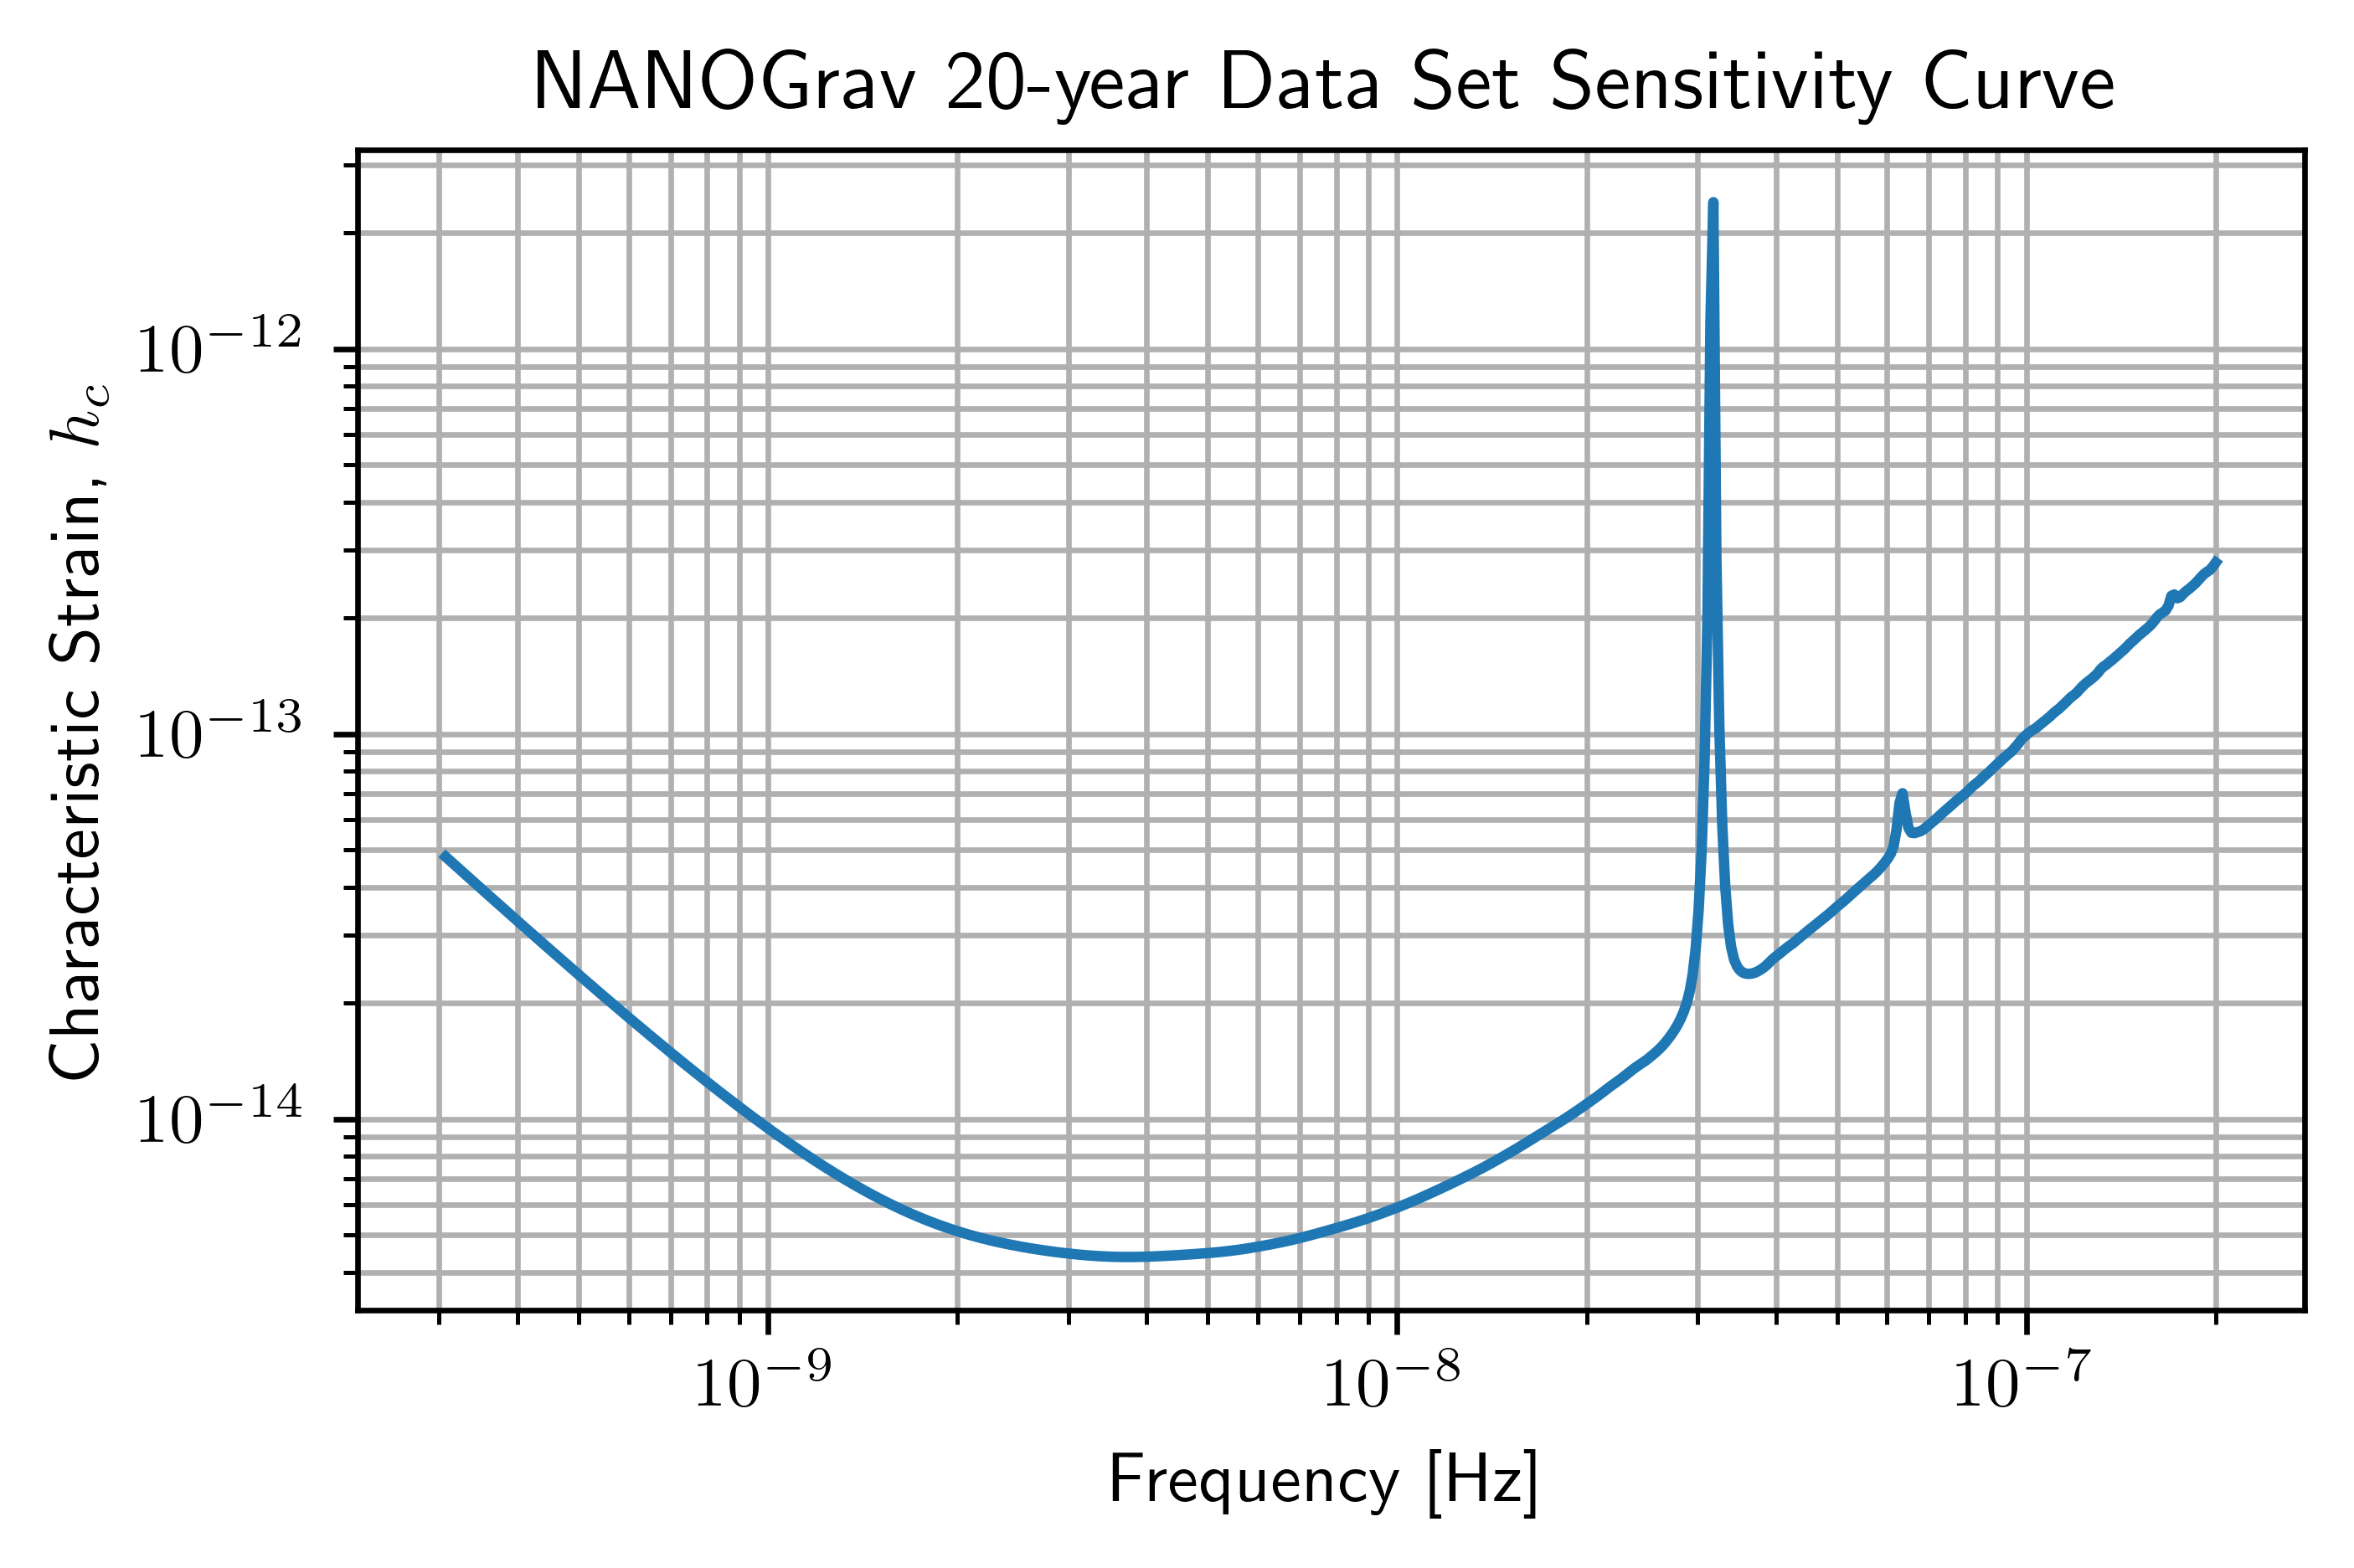

In [303]:
plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav 20-year Data Set Sensitivity Curve')
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.show()

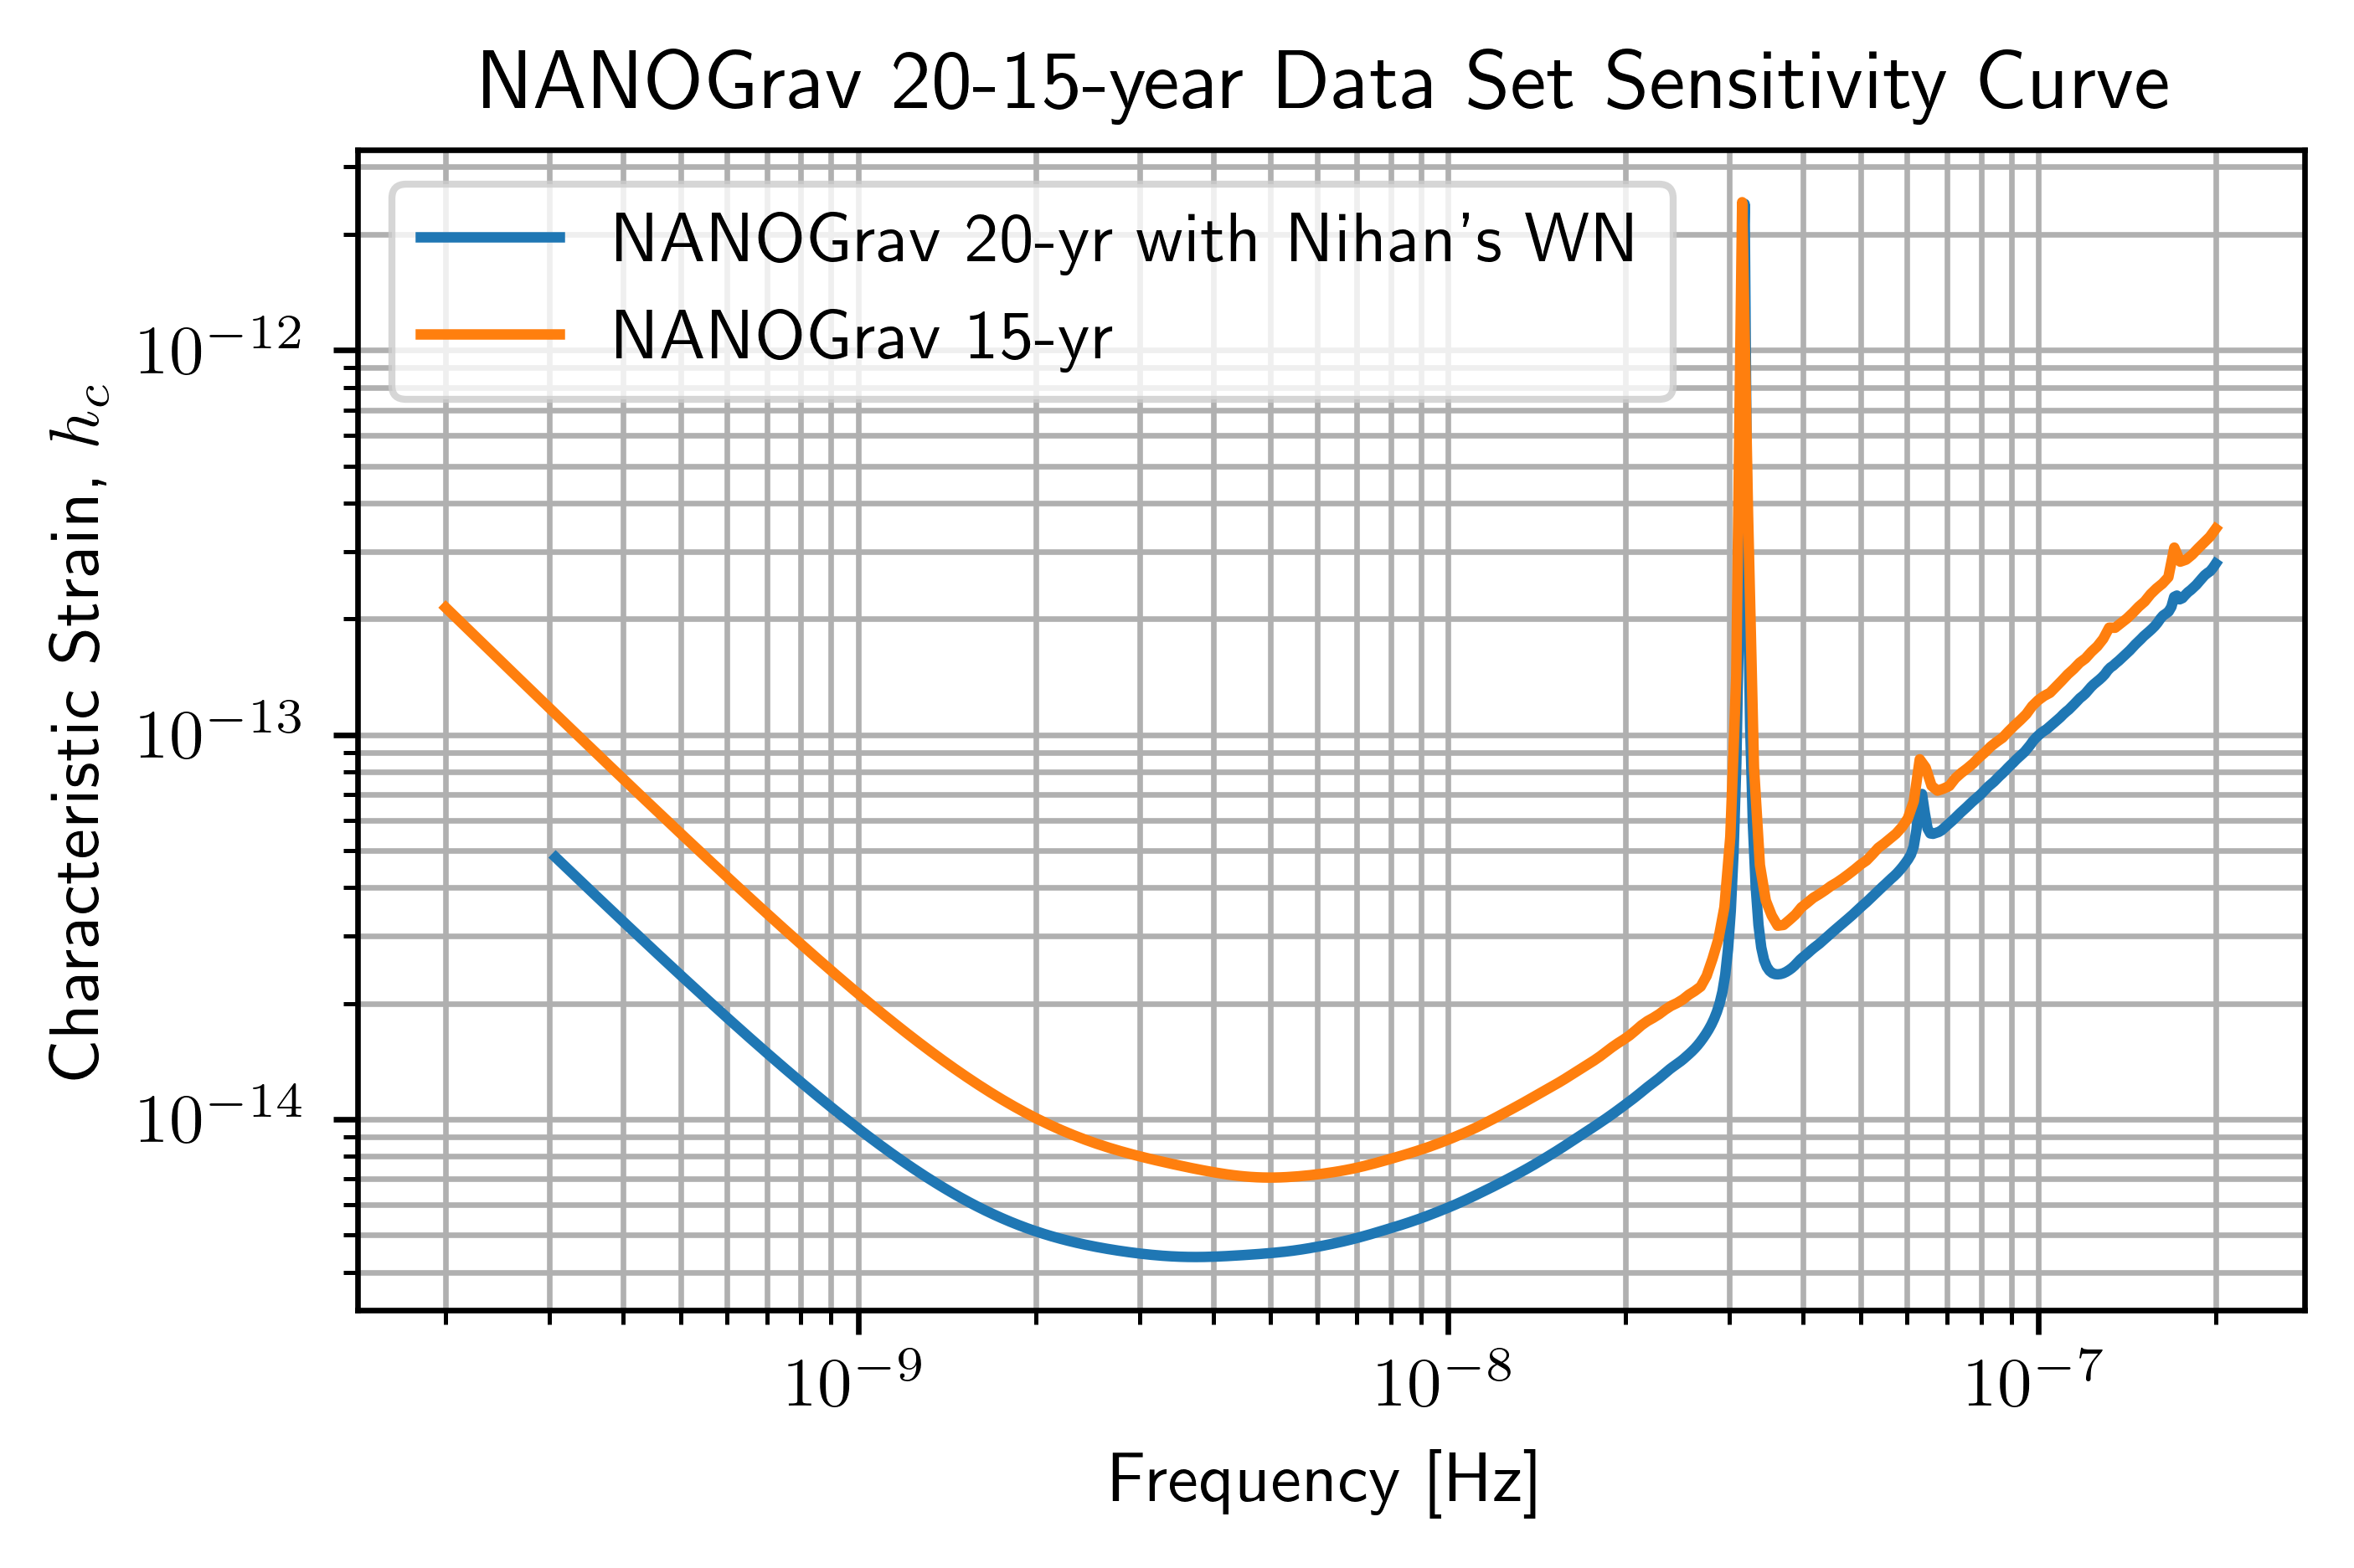

In [304]:
ng15_pkl_gwb = '/Users/ashokan/osu/sarahspta/ng15yr_v1p1_pint_logf_m2a_red_noise_vg_gwbsc.has' 
with open (ng15_pkl_gwb,'rb') as f:
    ng15_sc_gwb = pickle.load(f)

plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c,label='NANOGrav 20-yr with Nihan\'s WN')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav 20-15-year Data Set Sensitivity Curve')
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()

In [305]:
def get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects
        
    cutoff : float
        MJD cutoff for the calculation
    
    sigma_correction : ?
        ???
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    timespan = hsen.get_Tspan(psrs_cut)
    spectra = []
    for idx, p in enumerate(psrs_cut):
        sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
        sp.name = p.name
        _ = sp.NcalInv
        #print(f"psr spectra {idx} is done")
        spectra.append(sp)
    print(f"PTA spectrum with {len(spectra)} psrs created.")
    return spectra

In [306]:
end_mjd = 59033
psr_spectra = get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

PTA spectrum with 64 psrs created.


In [307]:
sliced_GWBSC = hsen.GWBSensitivityCurve(spectra=psr_spectra, orf='hd', autocorr=False)
A_gwb = 6.4e-15
gamma_gwb= 3.2 
alpha_gwb = (3. - gamma_gwb) / 2.
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
sliced_SNR = sliced_GWBSC.SNR(S_h)

In [308]:
sliced_SNR

np.longdouble('5.721630962725952')

In [309]:
print(len(psrs))
print(len(psr_spectra))

77
64


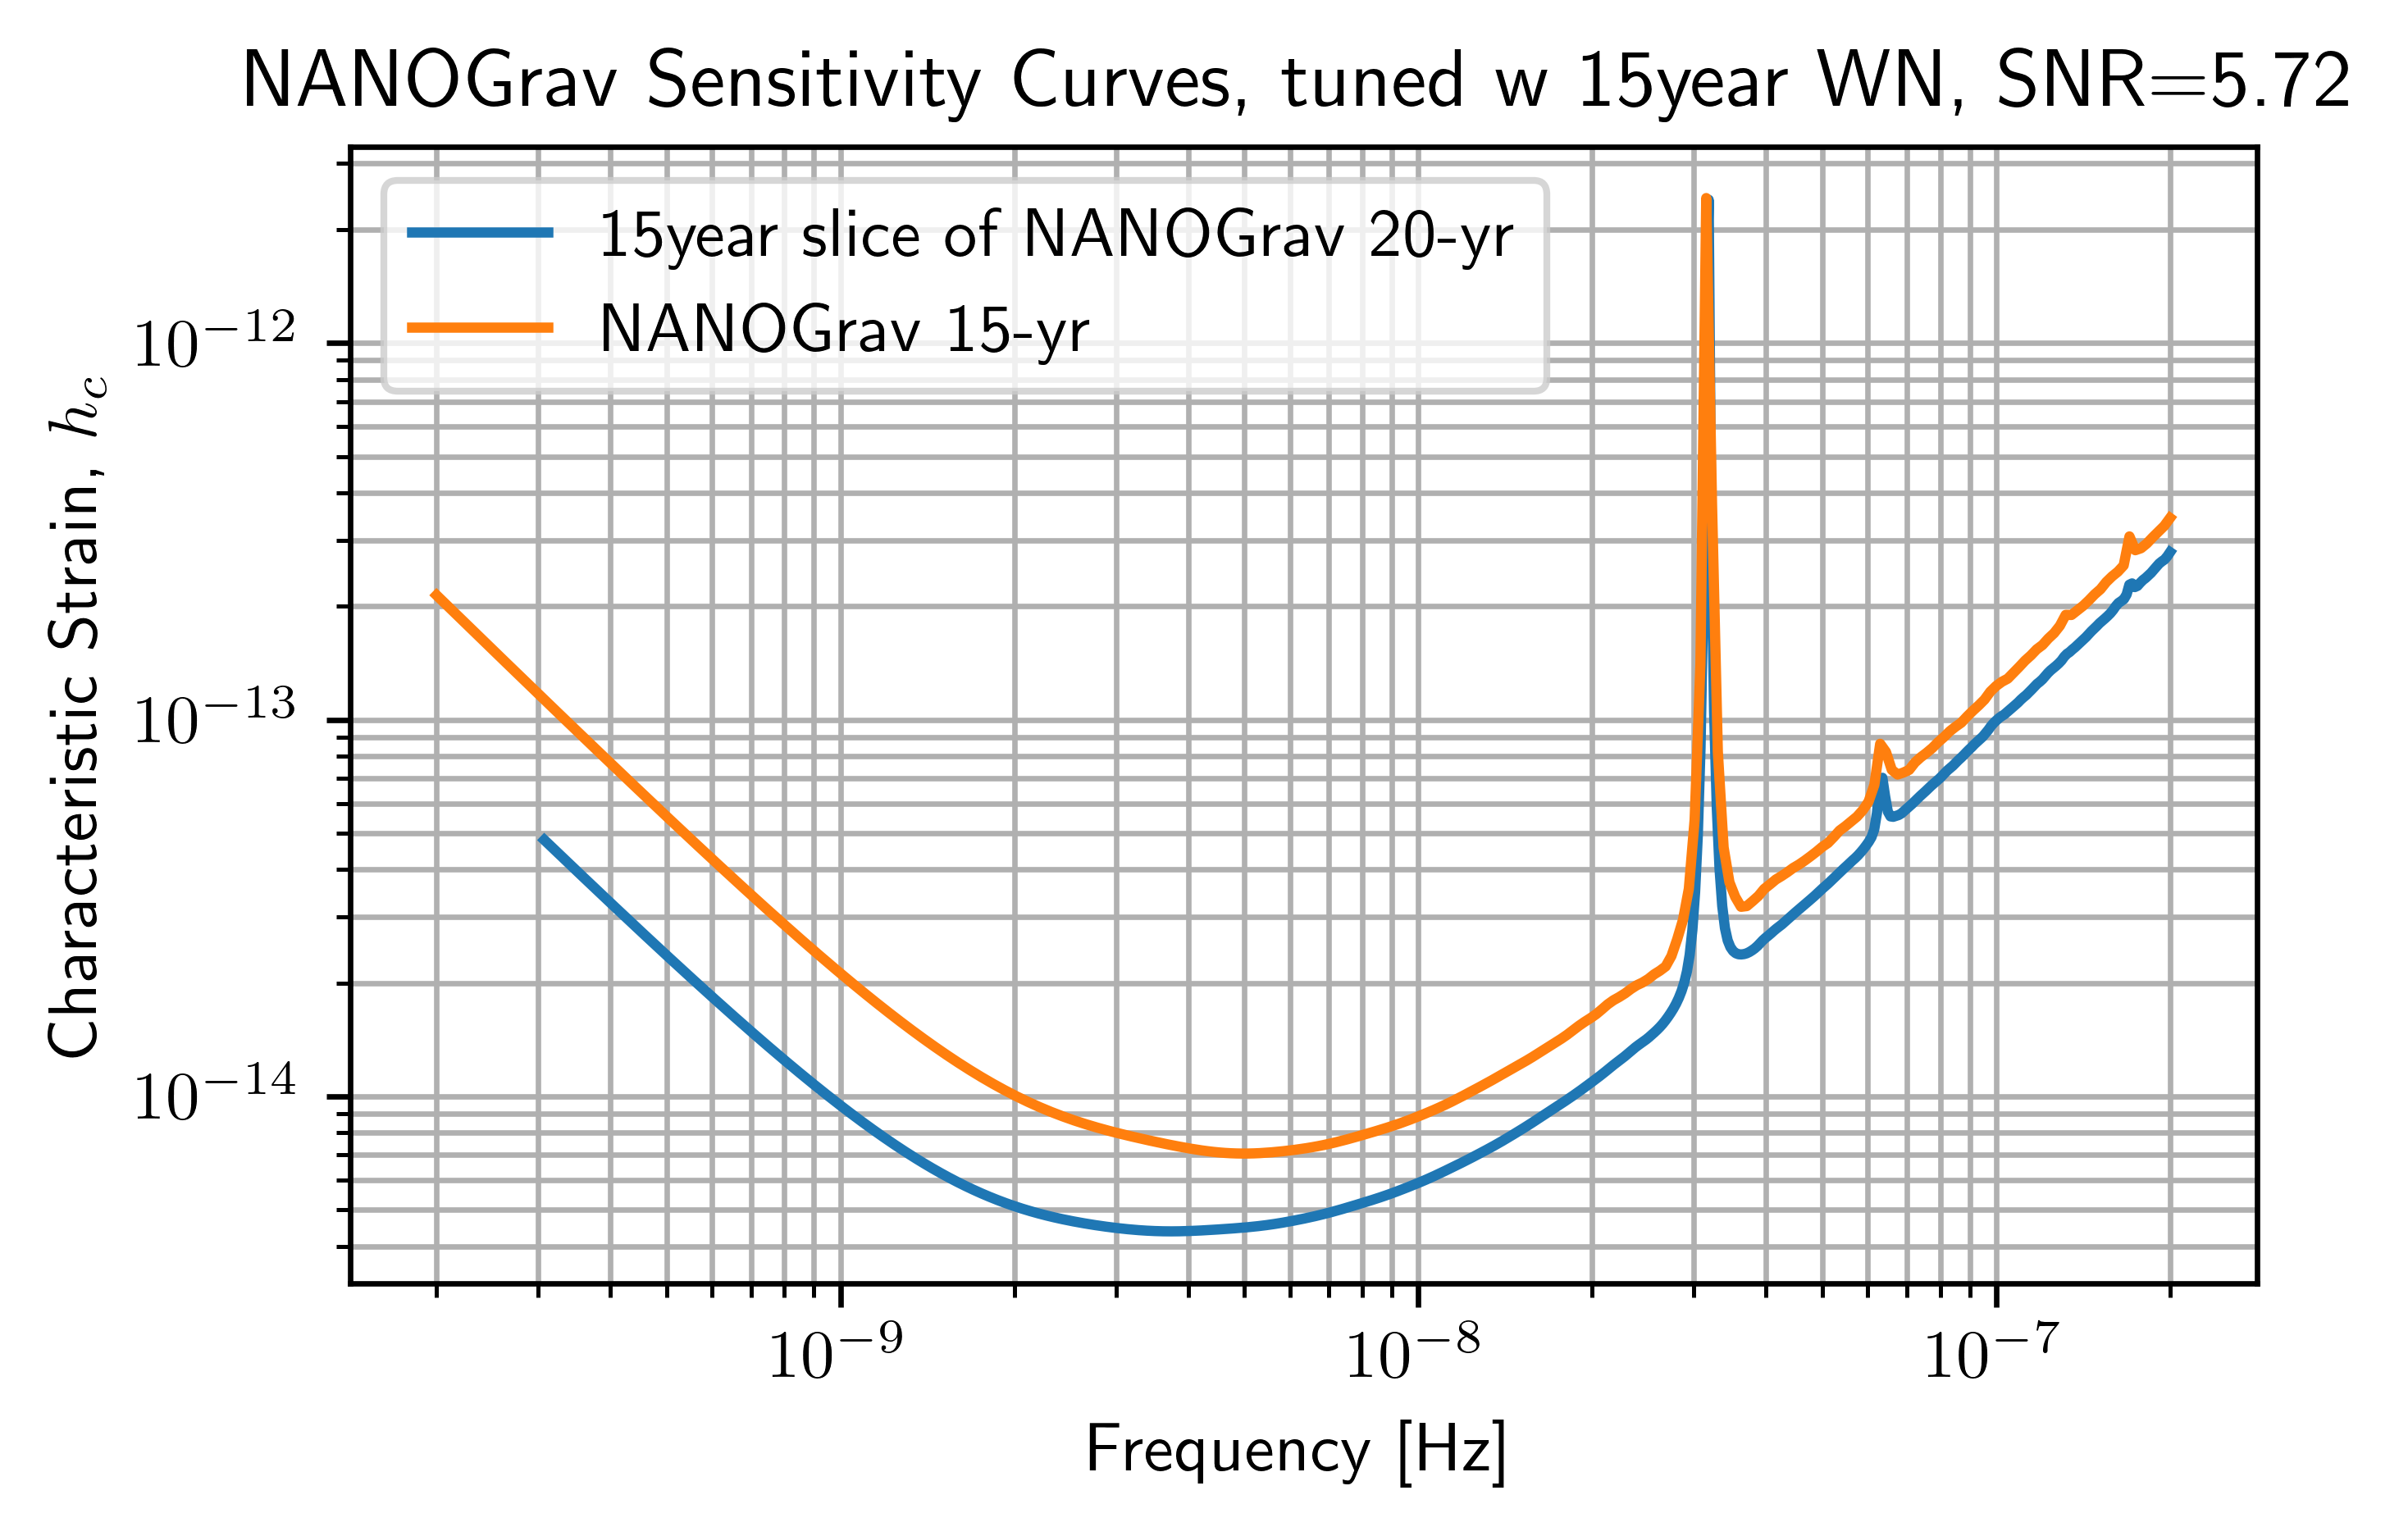

In [310]:
plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c,label='15year slice of NANOGrav 20-yr')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title(
'NANOGrav Sensitivity Curves, tuned w 15year WN, SNR={:.2f}'.format(
    sliced_SNR
)
)

#plt.title('NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}'.format(FACTOR),'SNR={:.2f}'.format(sliced_with_factor_SNR))

plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()

Lets tune its white noise.

In [312]:
def get_sliced_pulsars(psrs, 
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects

    start_mjd : float
        MJD start time for the calculation

    end_mjd : float
        MJD end time for the calculation
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    return psrs_cut
    

In [313]:
end_mjd = 59033
psrs_cut_NG15 = get_sliced_pulsars(psrs, 
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

In [314]:
def make_corr_our_tuning(psr,FACTOR=1.0):
    sigma_sqrt = (psr.toaerrs**2)*FACTOR
    corr = np.diag(sigma_sqrt)
    return corr

In [367]:
def make_corr_our_tuning_with_all_wn(psr,noise,FACTOR=1.0):
    N = psr.toaerrs.size
    corr = np.zeros((N,N))
    _, _, fl, _, bi = hsen.quantize_fast(psr.toas,psr.toaerrs,
                                         flags=psr.flags['f'],dt=1)
    keys = [ky for ky in noise.keys() if psr.name in ky]
    backends = np.unique(psr.flags['f'])
    sigma_sqr = np.zeros(N)
    ecorrs = np.zeros_like(fl,dtype=float)
    for be in backends:
        mask = np.where(psr.flags['f']==be)
        key_ef = '{0}_{1}_{2}'.format(psr.name,be,'efac')
        key_eq = '{0}_{1}_log10_{2}'.format(psr.name,be,'equad')
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        sigma_sqr[mask] = (noise[key_ef]**2 * (FACTOR*(psr.toaerrs[mask]**2)
                           + (10**noise[key_eq])**2)+(10**nihans_noise[key_ec])**2)
        mask_ec = np.where(fl==be)
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        ecorrs[mask_ec] = np.ones_like(mask_ec) * (10**noise[key_ec])
    j = [ecorrs[ii]**2*np.ones((len(bucket),len(bucket)))
         for ii, bucket in enumerate(bi)]

    J = sl.block_diag(*j)
    corr = np.diag(sigma_sqr) + J
    return corr

Lets try to chop enterprise pulsars instead of hasasia pulsars.

In [368]:
epsrs_cut_NG15 = []
epsrs_copy = copy.deepcopy(ePsrs)

for ePsr in epsrs_copy:
    ePsr.filter_data(start_time=0, end_time=end_mjd)
    epsrs_cut_NG15.append(ePsr)

In [369]:
for i in range(len(epsrs_cut_NG15)):
    print(epsrs_cut_NG15[i].name) 

B1855+09
B1953+29
J0023+0923
J0030+0451
J0102+4839
J0125-2327
J0154+1833
J0218+4232
J0340+4130
J0406+3039
J0437-4715
J0509+0856
J0557+1551
J0605+3757
J0610-2100
J0613-0200
J0614-3329
J0621+2514
J0636+5128
J0645+5158
J0709+0458
J0732+2314
J0740+6620
J0751+1807
J0931-1902
J1012-4235
J1022+1001
J1024-0719
J1125+7819
J1312+0051
J1453+1902
J1455-3330
J1600-3053
J1614-2230
J1630+3734
J1640+2224
J1643-1224
J1705-1903
J1713+0747
J1719-1438
J1730-2304
J1738+0333
J1741+1351
J1744-1134
J1745+1017
J1747-4036
J1751-2857
J1802-2124
J1803+1358
J1811-2405
J1832-0836
J1843-1113
J1853+1303
J1903+0327
J1909-3744
J1910+1256
J1911+1347
J1911-1114
J1918-0642
J1923+2515
J1944+0907
J1946+3417
J2010-1323
J2017+0603
J2022+2534
J2033+1734
J2039-3616
J2043+1711
J2124-3358
J2150-0326
J2214+3000
J2229+2643
J2234+0611
J2234+0944
J2302+4442
J2317+1439
J2322+2057


In [370]:
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
for ePsr in epsrs_cut_NG15:
    #corr = make_corr_our(ePsr)[::thin,::thin]
    print('working on pulsar', ePsr.name)
    if ePsr.name == "J1911-1114":
        continue
    else:
        nihans_corr = make_corr(ePsr,nihans_noise)
        plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
        if ePsr.name in rn_psrs.keys():
            Amp, gam = rn_psrs[ePsr.name]
            plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

        nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                                toas=ePsr.toas[::thin])
        psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                        toaerrs=ePsr.toaerrs[::thin],
                        phi=ePsr.phi,theta=ePsr.theta,
                        N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
        psr.name = ePsr.name
        psrs.append(psr)
        del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

working on pulsar B1855+09
PSR B1855+09 completeworking on pulsar B1953+29
PSR B1953+29 completeworking on pulsar J0023+0923
PSR J0023+0923 completeworking on pulsar J0030+0451
PSR J0030+0451 completeworking on pulsar J0102+4839
PSR J0102+4839 completeworking on pulsar J0125-2327
PSR J0125-2327 completeworking on pulsar J0154+1833
PSR J0154+1833 completeworking on pulsar J0218+4232
PSR J0218+4232 completeworking on pulsar J0340+4130
PSR J0340+4130 completeworking on pulsar J0406+3039
PSR J0406+3039 completeworking on pulsar J0437-4715
PSR J0437-4715 completeworking on pulsar J0509+0856
PSR J0509+0856 completeworking on pulsar J0557+1551
PSR J0557+1551 completeworking on pulsar J0605+3757
PSR J0605+3757 completeworking on pulsar J0610-2100
PSR J0610-2100 completeworking on pulsar J0613-0200
PSR J0613-0200 completeworking on pulsar J0614-3329
PSR J0614-3329 completeworking on pulsar J0621+2514
PSR J0621+2514 completeworking on pulsar J0636+5128
PSR J0636+5128 completeworking on pulsar J0

In [371]:
specs = []
for p in psrs:
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    print('\rPSR {0} complete'.format(p.name),end='',flush=True)

PSR J2322+2057 complete

In [372]:
ng15_slice_ng20_sarah_nihans_wn = hsen.GWBSensitivityCurve(specs)

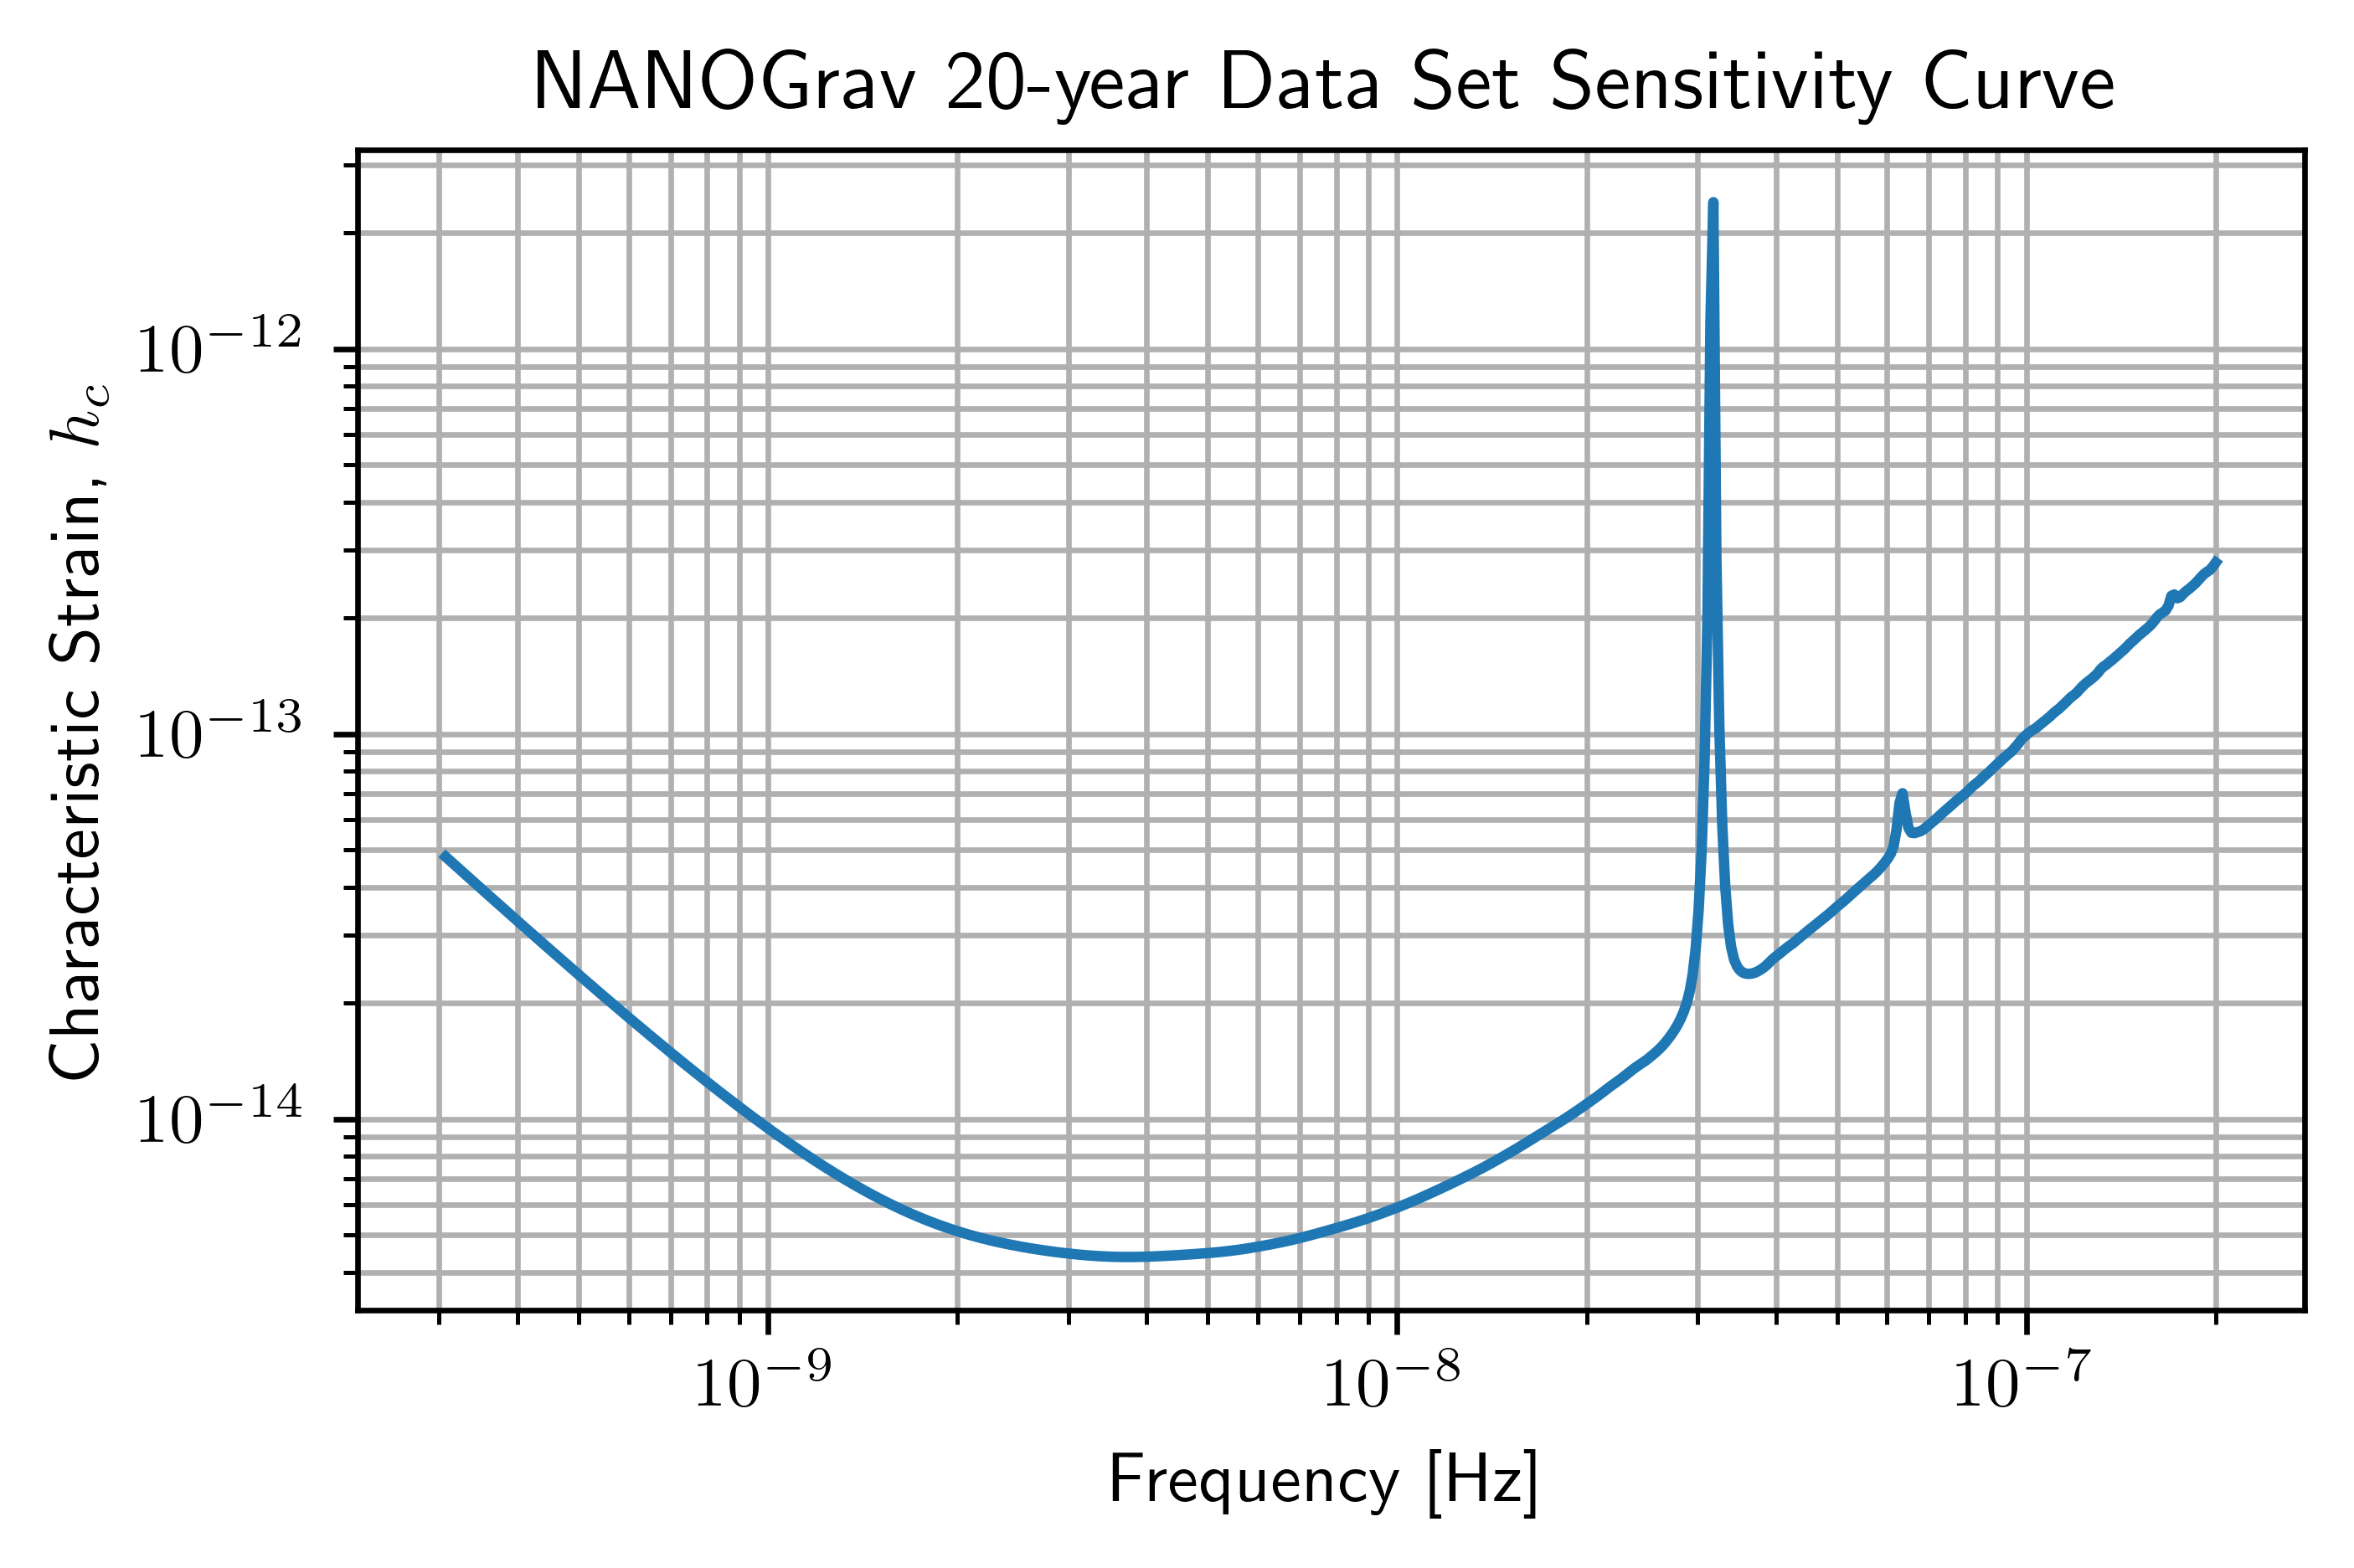

In [373]:
plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav 20-year Data Set Sensitivity Curve')
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.show()

Loop over prefactors

FACTOR =  1.285029041906499
PSR J2322+2057 complete

sliced_with_factor_SNR =  5.2598050317558265


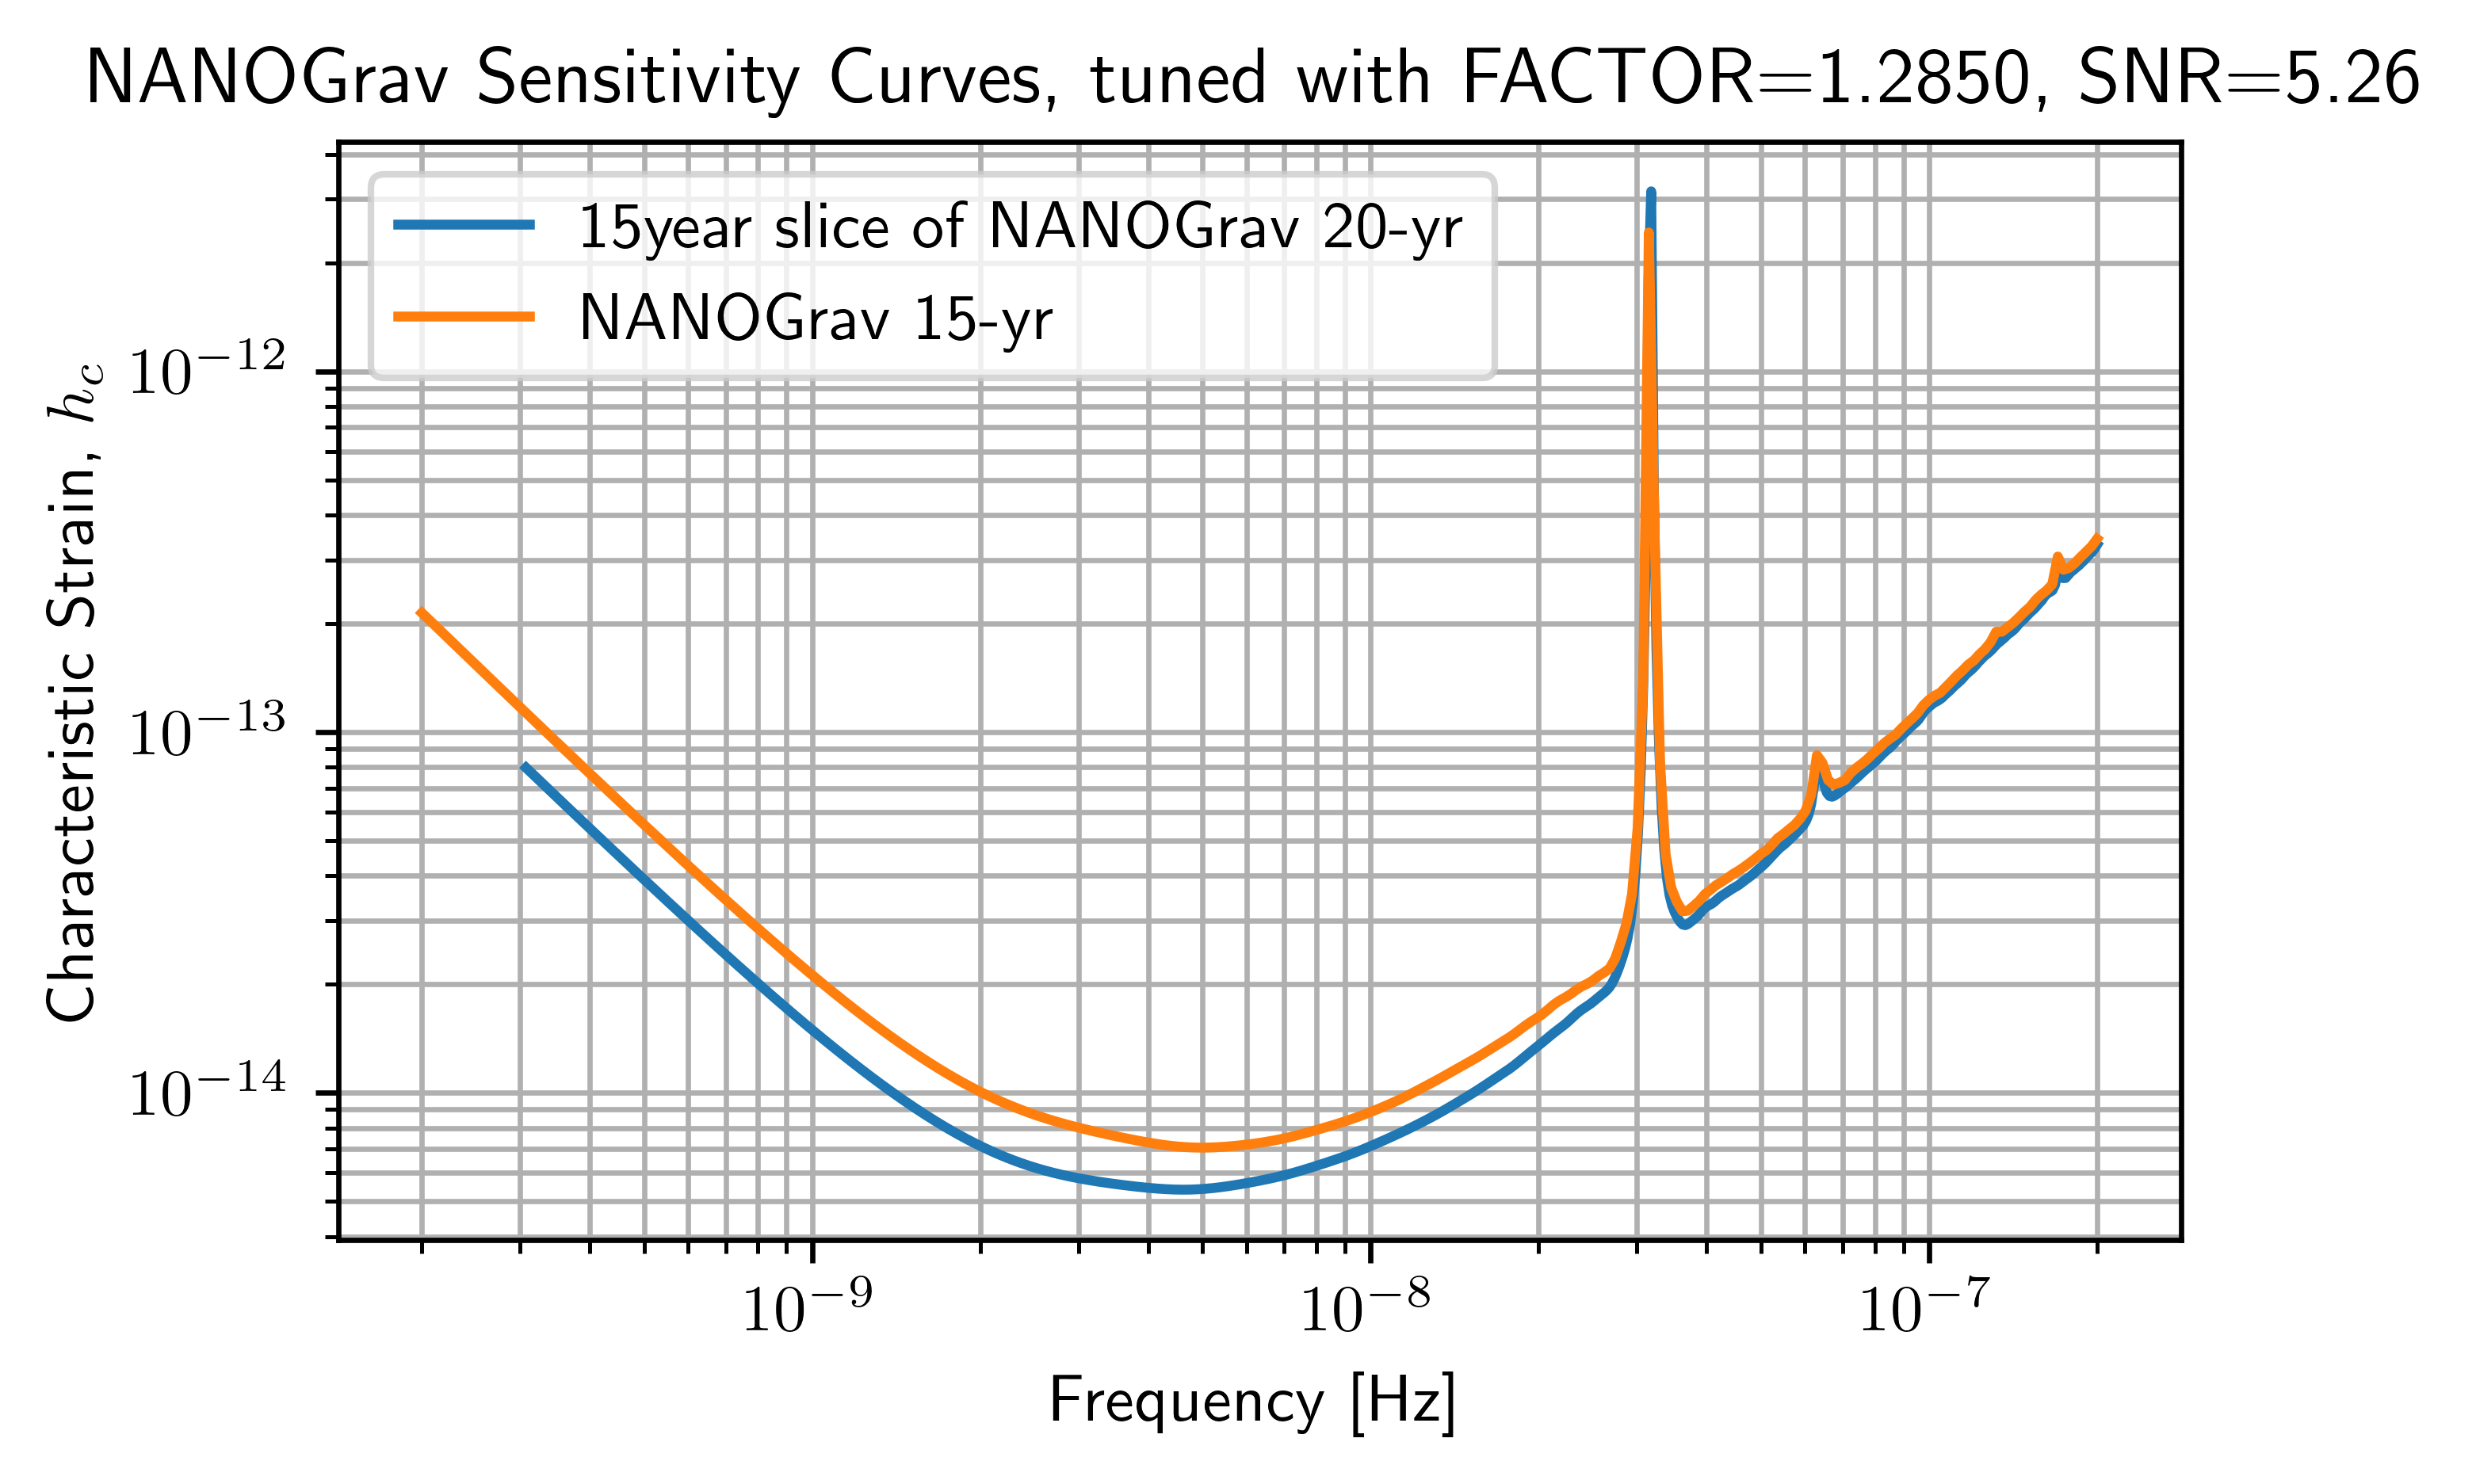

FACTOR =  1.5420348502877987
PSR J2322+2057 complete

sliced_with_factor_SNR =  5.034818754386341


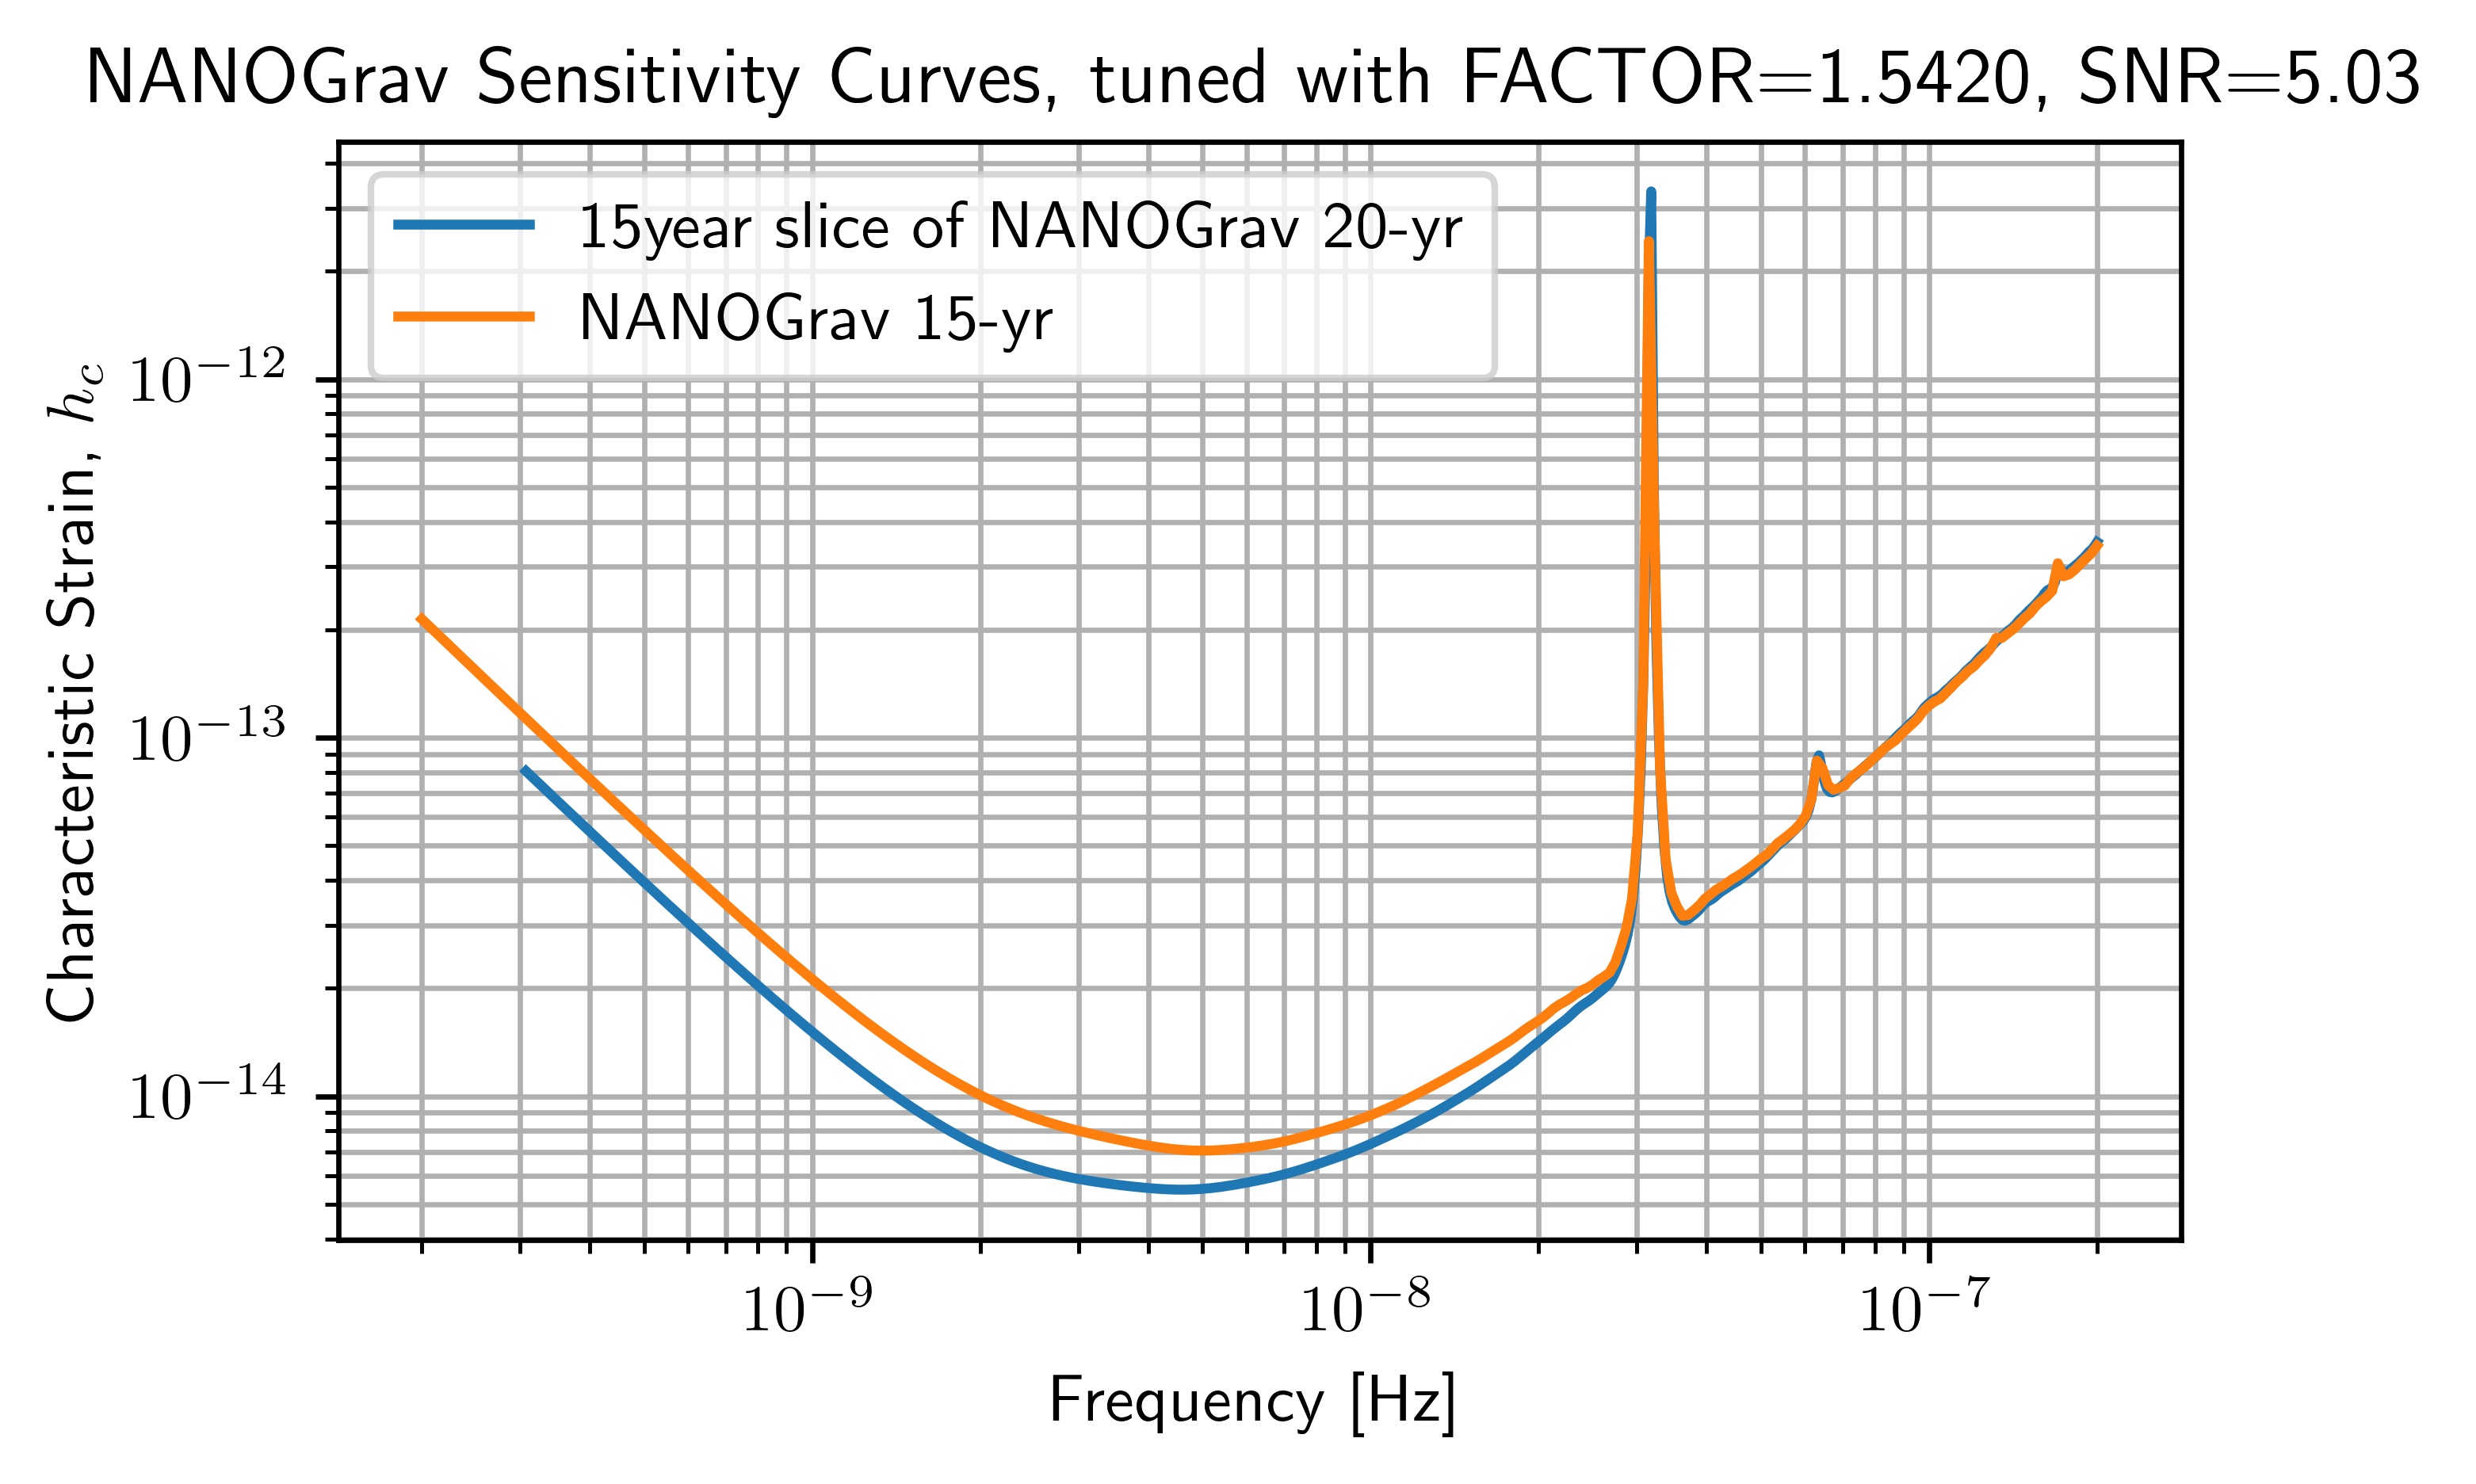

FACTOR =  1.7990406586690983
PSR J2322+2057 complete

sliced_with_factor_SNR =  4.842987346354809


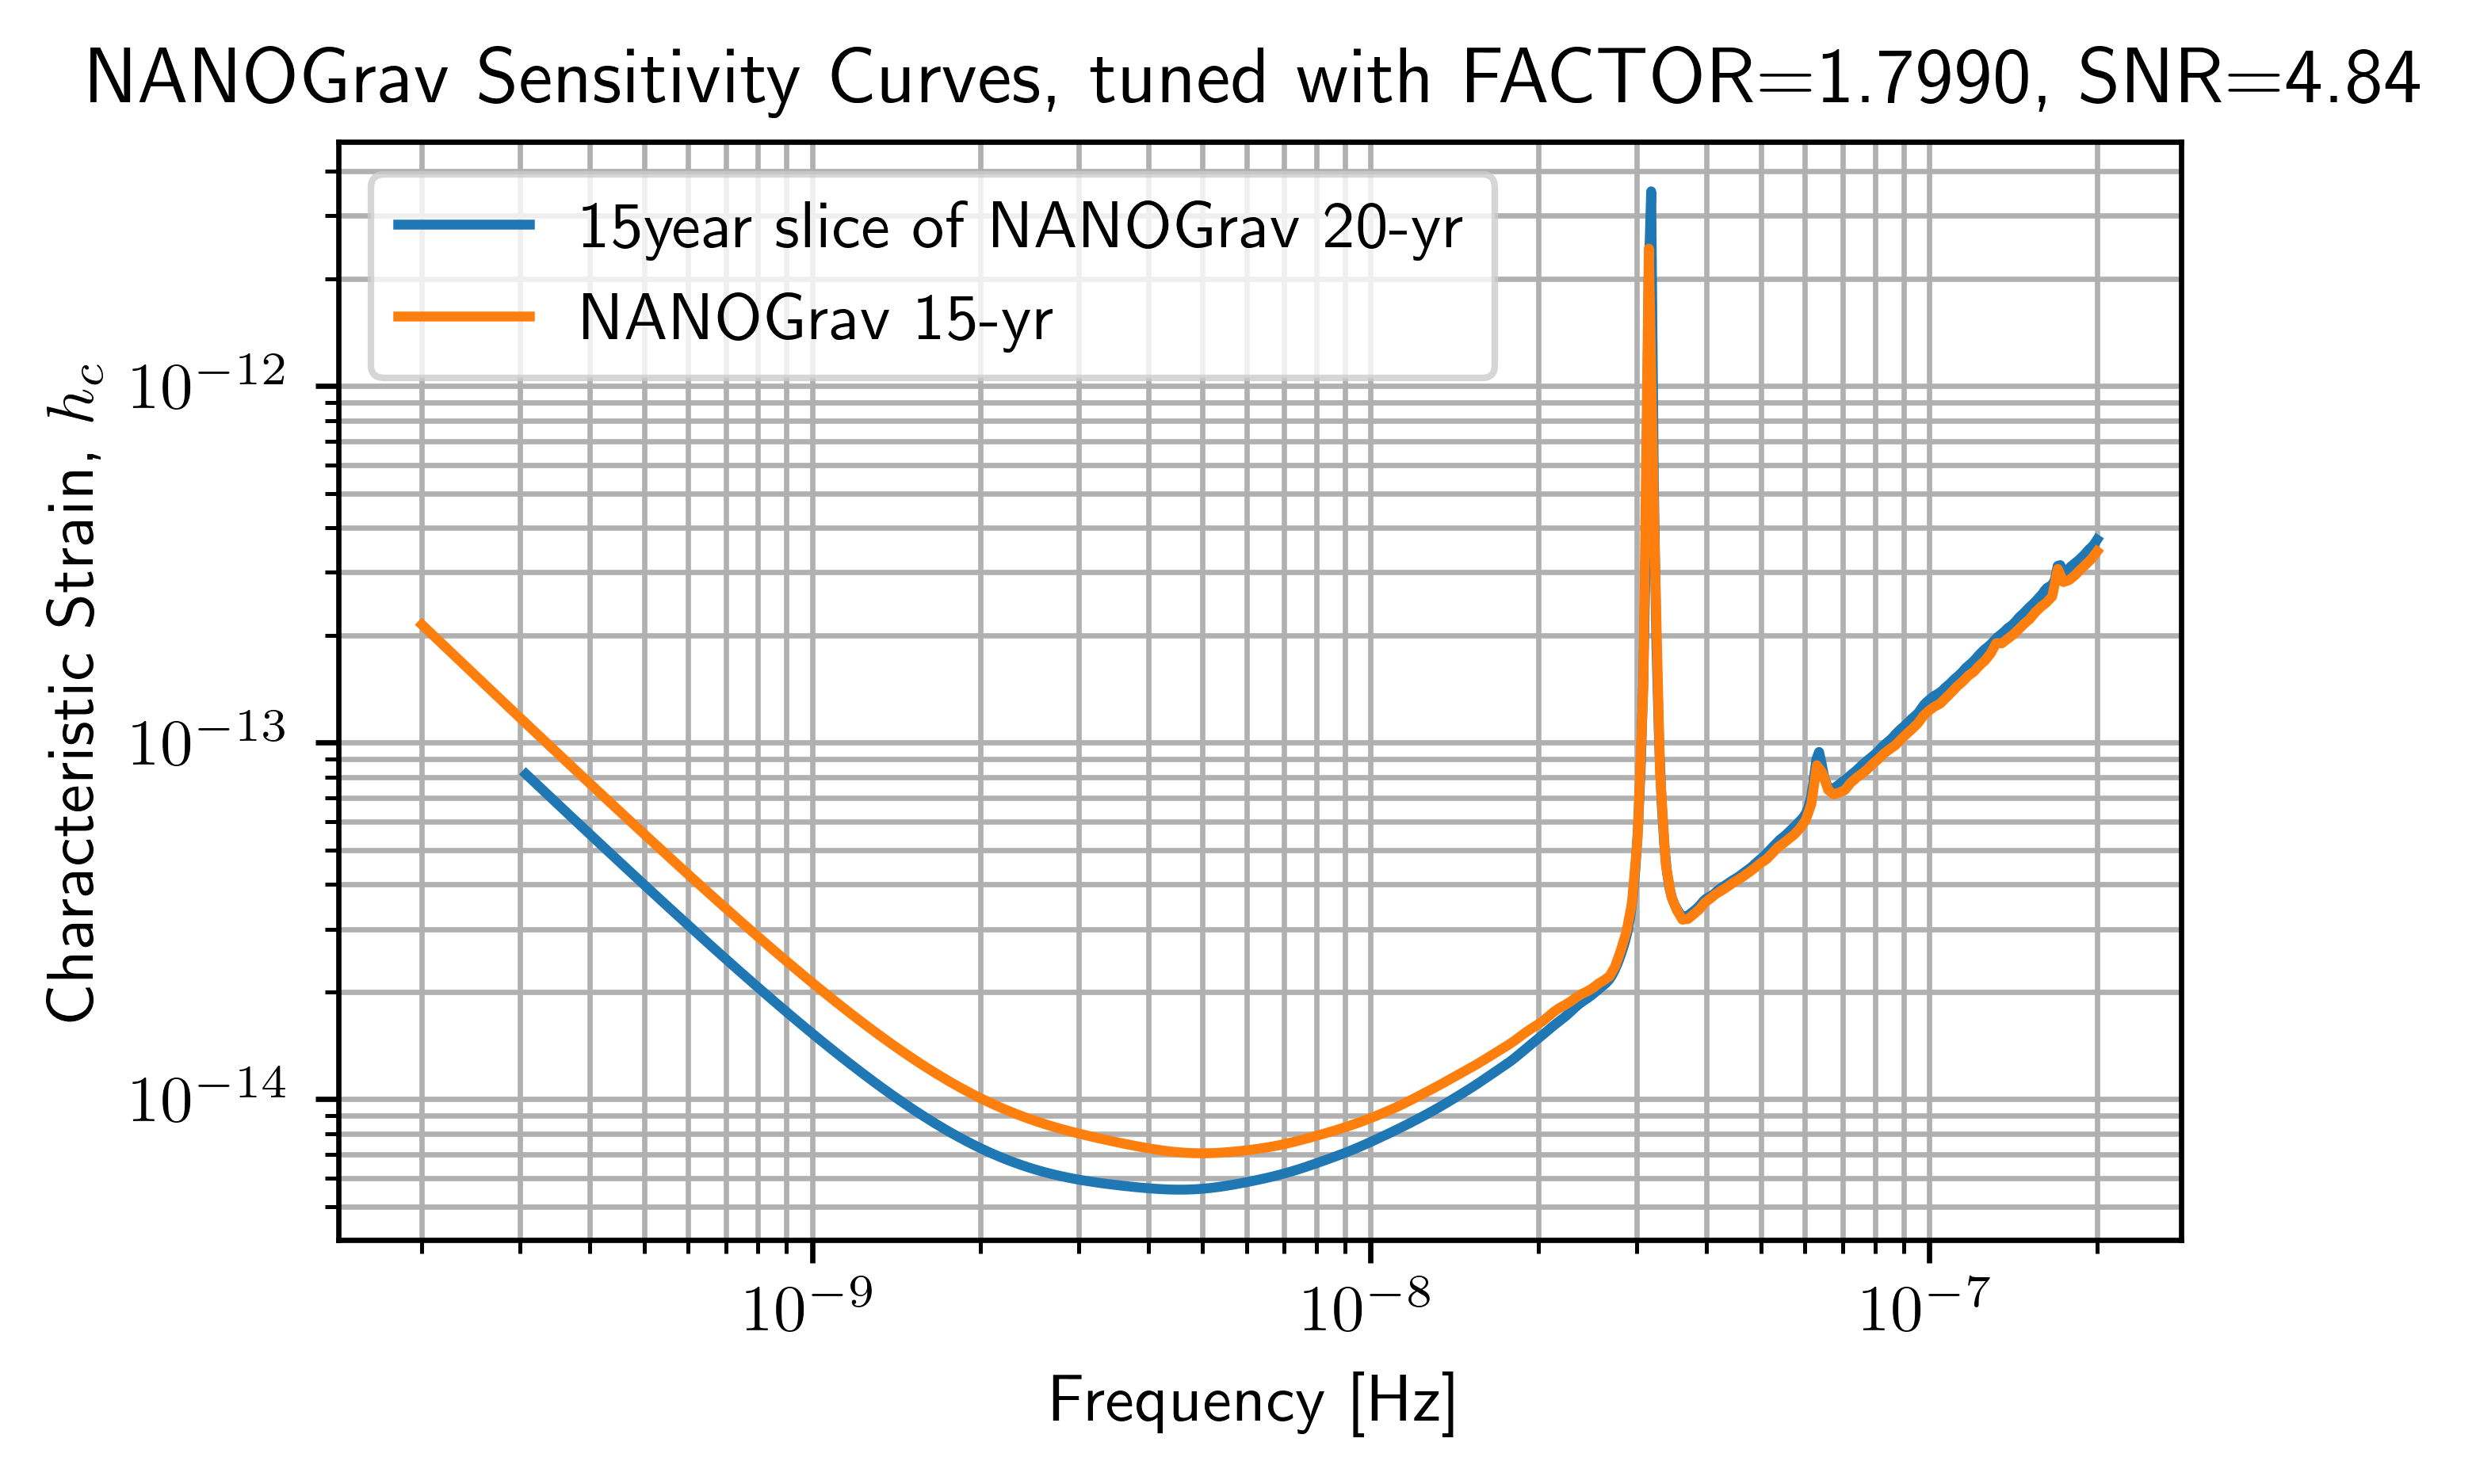

In [378]:
sliced_15yr_SNRS = []
for prefactor in [0.5,0.6,0.7]:
    FACTOR = prefactor*1.45*np.sqrt(np.pi)
    print("FACTOR = ", FACTOR)    
    A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
    psrs = []
    thin = 1
    for ePsr in epsrs_cut_NG15:
        #corr = make_corr_our(ePsr)[::thin,::thin]
        #print('working on pulsar', ePsr.name)
        if ePsr.name == "J1911-1114":
            continue
        else:
            nihans_corr = make_corr_our_tuning_with_all_wn(ePsr,nihans_noise,FACTOR=FACTOR)
            plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
            if ePsr.name in rn_psrs.keys():
                Amp, gam = rn_psrs[ePsr.name]
                plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

            nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                                    toas=ePsr.toas[::thin])
            psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                            toaerrs=ePsr.toaerrs[::thin],
                            phi=ePsr.phi,theta=ePsr.theta,
                            N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
            psr.name = ePsr.name
            psrs.append(psr)
            del ePsr
        print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

    specs = []
    for p in psrs:
        sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
        _ = sp.NcalInv
        specs.append(sp)
        #print('\rPSR {0} complete'.format(p.name),end='',flush=True)

    ng20_sarah_sc_with_factor = hsen.GWBSensitivityCurve(specs)
    sliced_with_factor_SNR = ng20_sarah_sc_with_factor.SNR(S_h)
    sliced_15yr_SNRS.append(sliced_with_factor_SNR)
    print("sliced_with_factor_SNR = ", sliced_with_factor_SNR)

    plt.loglog(ng20_sarah_sc_with_factor.freqs,ng20_sarah_sc_with_factor.h_c,label='15year slice of NANOGrav 20-yr')
    plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Characteristic Strain, $h_c$')
    plt.title(
    'NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}, SNR={:.2f}'.format(
        FACTOR, sliced_with_factor_SNR
    )
)
    #plt.title('NANOGrav 20-15-year Data Set Sensitivity Curve, tuned with FACTOR={0}'.format(FACTOR))
    plt.grid(which='both')
    # plt.ylim(1e-15,9e-12)
    plt.legend()
    plt.show()